# Прогнозирование убытков при страховании от пожара
Крючков А.В.

## Итоговый проект первого года обучения

Заказчик: Страховая компания

Цель: Спрогнозировать ожидаемые убытки от пожара для страховых полисов

Задача: Спрогнозировать преобразованное соотношение убытков к общей застрахованной стоимости (называемое «целевым значением» -  переменная "target" - в наборе данных).

Данные: характеристики (признаки) страхуемых объектов, включают характеристики полиса, погодные условия, геодемографические данные и информацию об уровне преступности.

Признаки:

 - id : Уникальный идентификатор набора данных

 - target : Целевой показатель - отношение убытка к общей застрахованной стоимости.

 - var1 – var10 : Набор переменных, представляющих характеристики полиса;
 
 - var11 — вес, используемый при расчете взвешенного индекса Джини;

 - geodemVar1 – geodemVar10 : Набор геодемографических переменных;

 - weatherVar1 – weatherVar10 : Набор переменных метеостанции;

 - crimeVar1 – crimeVar5 : набор переменных уровня преступности.

Метрика оценки качества моделей: RMSLE (Root Mean Squared Log Error):
$$RMSLE = \sqrt{\frac{1}{n}\sum_{i=1}^n(log(y_i+1)-log(\hat{y_i}+1))^2}$$
где:

* $y_i$ - истинное значение целевого признака (target)

* $\hat{y_i}$ - предсказанная i-го значения целевого признака 

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

import category_encoders as ce
from sklearn.impute import SimpleImputer
from sklearn import model_selection
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import preprocessing
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import SelectKBest, f_regression, f_classif, chi2
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import optuna
import time
import pickle
from sklearn.pipeline import Pipeline, make_pipeline

from sklearn.base import TransformerMixin, BaseEstimator

c:\Users\kryuc\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data= pd.read_csv('data/data_mod.csv')
data

,id,target,var1,var2,var3,var4,var5,var6,var7,var8,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,1,0.0,0,Z,0,N1,Z,Z,3,1,...,2.711295,0.902699,2.682806,1.036433,2.624847,0.868651,0.625186,0.685535,0.698889,1.322650
1,2,0.0,0,Z,0,C1,Z,Z,3,2,...,2.370791,0.894850,2.690246,1.003267,2.569522,1.049803,0.668872,0.902722,0.658104,1.679865
2,3,0.0,3,Z,4,J3,B,B,2,4,...,0.911176,0.753558,0.807826,1.015704,0.926616,1.887331,1.513871,1.274002,1.256733,1.046967
3,4,0.0,3,Z,4,H1,B,Z,3,4,...,0.197981,2.394116,0.872650,0.671609,0.207778,1.659096,1.341626,0.957322,1.328928,0.661204
4,5,0.0,0,Z,0,H1,Z,Z,2,4,...,1.209454,0.682912,1.206430,1.173242,1.762718,0.894055,1.380088,1.133255,1.249629,1.258417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452056,902782,0.0,0,Z,0,D3,Z,Z,3,2,...,1.685407,1.012593,1.499616,0.883041,1.111944,0.919645,0.563916,0.767313,0.739102,0.572656
452057,902785,0.0,3,Z,0,H1,Z,B,3,4,...,0.892448,1.177434,1.037533,0.920353,0.689902,0.669145,0.430252,0.345801,0.638615,0.567431
452058,902786,0.0,3,Z,3,I1,B,B,2,5,...,0.842545,1.687655,2.131244,0.870604,0.933956,1.597548,1.374252,0.950042,1.448644,1.294374
452059,902787,0.0,0,Z,0,H1,Z,Z,3,4,...,0.473174,0.839903,0.423182,1.090328,0.465649,0.912543,0.856095,1.426883,1.147865,1.290110


## 1. Очистка, исследование и предобработка данных

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 452061 entries, 0 to 452060
Data columns (total 38 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            452061 non-null  int64  
 1   target        452061 non-null  float64
 2   var1          452061 non-null  int64  
 3   var2          452061 non-null  str    
 4   var3          452061 non-null  int64  
 5   var4          452061 non-null  str    
 6   var5          452061 non-null  str    
 7   var6          452061 non-null  str    
 8   var7          452061 non-null  int64  
 9   var8          452061 non-null  int64  
 10  var9          452061 non-null  str    
 11  var10         452061 non-null  float64
 12  var11         452061 non-null  float64
 13  weatherVar1   450201 non-null  float64
 14  weatherVar2   450201 non-null  float64
 15  weatherVar3   450201 non-null  float64
 16  weatherVar4   449989 non-null  float64
 17  weatherVar5   450201 non-null  float64
 18  weatherVar6   4

In [4]:
#Удалим неинформационный столбец id
data = data.drop('id', axis=1)

In [5]:
#Проверим данные var1-var9
mask_var = [i for i in data.columns.to_list() if 'var' in i][:-2]
display(data[mask_var])

for col in mask_var:
    display(f'Уникальные значения признака {col} : {data[col].unique()}')


,var1,var2,var3,var4,var5,var6,var7,var8,var9
0,0,Z,0,N1,Z,Z,3,1,A
1,0,Z,0,C1,Z,Z,3,2,A
2,3,Z,4,J3,B,B,2,4,Z
3,3,Z,4,H1,B,Z,3,4,Z
4,0,Z,0,H1,Z,Z,2,4,A
...,...,...,...,...,...,...,...,...,...
452056,0,Z,0,D3,Z,Z,3,2,A
452057,3,Z,0,H1,Z,B,3,4,Z
452058,3,Z,3,I1,B,B,2,5,Z
452059,0,Z,0,H1,Z,Z,3,4,A


'Уникальные значения признака var1 : [0 3 2 4 1 5]'

"Уникальные значения признака var2 : <StringArray>\n['Z', 'A', 'B', 'C']\nLength: 4, dtype: str"

'Уникальные значения признака var3 : [0 4 3 5 2 6 1]'

"Уникальные значения признака var4 : <StringArray>\n['N1', 'C1', 'J3', 'H1', 'A1', 'H2', 'E3', 'M1', 'R3', 'I1', 'J4', 'D3', 'R6',\n 'O2', 'F1', 'R5',  'Z', 'H3', 'D1', 'P1', 'J5', 'J2', 'E2', 'S1', 'E1', 'L1',\n 'G1', 'D2', 'O1', 'B1', 'G2', 'E6', 'K1', 'D4', 'E5', 'J1', 'E4', 'R7', 'R2',\n 'R8', 'J6', 'R1', 'R4']\nLength: 43, dtype: str"

"Уникальные значения признака var5 : <StringArray>\n['Z', 'B', 'D', 'E', 'C', 'A', 'F']\nLength: 7, dtype: str"

"Уникальные значения признака var6 : <StringArray>\n['Z', 'B', 'A', 'C']\nLength: 4, dtype: str"

'Уникальные значения признака var7 : [3 2 4 7 5 1 6 8 0]'

'Уникальные значения признака var8 : [1 2 4 3 6 0 5]'

"Уникальные значения признака var9 : <StringArray>\n['A', 'Z', 'B']\nLength: 3, dtype: str"

В данных:
 - признаки var1, var3, var7, var8  - порядковые;
 - признаки var2, var4, var5, var6, var9 - категориальные, из котрых var4 имеет 43 уникальных значения, которые нужно кодировать двоичной кодировкой, остальные dummy.
 
Требуют предобработки


In [6]:
#количесвто пропусков в данных
display(f'Количество пропусков в данных {data.isna().sum().sum()}')

'Количество пропусков в данных 598321'

In [7]:
#Геодемографические данные
mask_geodem = [i for i in data.columns.to_list() if 'geodem' in i]

#Метеорологические данные
mask_weather = [i for i in data.columns.to_list() if 'weather' in i]

#Данные о криминальной обстановке
mask_crime = [i for i in data.columns.to_list() if 'crime' in i]



In [8]:
#Заполним пропущенные значения числовых признаков медианными значениями

myImputer = SimpleImputer (strategy='median')

data[['var10', 'var11']] = myImputer.fit_transform(data[['var10', 'var11']])
data[mask_geodem] = myImputer.fit_transform(data[mask_geodem])
data[mask_weather] = myImputer.fit_transform(data[mask_weather])
data[mask_crime] = myImputer.fit_transform(data[mask_crime])

data

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,0.0,0,Z,0,N1,Z,Z,3,1,A,...,2.711295,0.902699,2.682806,1.036433,2.624847,0.868651,0.625186,0.685535,0.698889,1.322650
1,0.0,0,Z,0,C1,Z,Z,3,2,A,...,2.370791,0.894850,2.690246,1.003267,2.569522,1.049803,0.668872,0.902722,0.658104,1.679865
2,0.0,3,Z,4,J3,B,B,2,4,Z,...,0.911176,0.753558,0.807826,1.015704,0.926616,1.887331,1.513871,1.274002,1.256733,1.046967
3,0.0,3,Z,4,H1,B,Z,3,4,Z,...,0.197981,2.394116,0.872650,0.671609,0.207778,1.659096,1.341626,0.957322,1.328928,0.661204
4,0.0,0,Z,0,H1,Z,Z,2,4,A,...,1.209454,0.682912,1.206430,1.173242,1.762718,0.894055,1.380088,1.133255,1.249629,1.258417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452056,0.0,0,Z,0,D3,Z,Z,3,2,A,...,1.685407,1.012593,1.499616,0.883041,1.111944,0.919645,0.563916,0.767313,0.739102,0.572656
452057,0.0,3,Z,0,H1,Z,B,3,4,Z,...,0.892448,1.177434,1.037533,0.920353,0.689902,0.669145,0.430252,0.345801,0.638615,0.567431
452058,0.0,3,Z,3,I1,B,B,2,5,Z,...,0.842545,1.687655,2.131244,0.870604,0.933956,1.597548,1.374252,0.950042,1.448644,1.294374
452059,0.0,0,Z,0,H1,Z,Z,3,4,A,...,0.473174,0.839903,0.423182,1.090328,0.465649,0.912543,0.856095,1.426883,1.147865,1.290110


In [9]:
# Удалим строки с пропусками в остальлных признаках, так как нам не извеснтен смысл этих признаков, восстановить пропущенные значения не возможно
data = data.dropna(axis=0)
data

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,0.0,0,Z,0,N1,Z,Z,3,1,A,...,2.711295,0.902699,2.682806,1.036433,2.624847,0.868651,0.625186,0.685535,0.698889,1.322650
1,0.0,0,Z,0,C1,Z,Z,3,2,A,...,2.370791,0.894850,2.690246,1.003267,2.569522,1.049803,0.668872,0.902722,0.658104,1.679865
2,0.0,3,Z,4,J3,B,B,2,4,Z,...,0.911176,0.753558,0.807826,1.015704,0.926616,1.887331,1.513871,1.274002,1.256733,1.046967
3,0.0,3,Z,4,H1,B,Z,3,4,Z,...,0.197981,2.394116,0.872650,0.671609,0.207778,1.659096,1.341626,0.957322,1.328928,0.661204
4,0.0,0,Z,0,H1,Z,Z,2,4,A,...,1.209454,0.682912,1.206430,1.173242,1.762718,0.894055,1.380088,1.133255,1.249629,1.258417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
452056,0.0,0,Z,0,D3,Z,Z,3,2,A,...,1.685407,1.012593,1.499616,0.883041,1.111944,0.919645,0.563916,0.767313,0.739102,0.572656
452057,0.0,3,Z,0,H1,Z,B,3,4,Z,...,0.892448,1.177434,1.037533,0.920353,0.689902,0.669145,0.430252,0.345801,0.638615,0.567431
452058,0.0,3,Z,3,I1,B,B,2,5,Z,...,0.842545,1.687655,2.131244,0.870604,0.933956,1.597548,1.374252,0.950042,1.448644,1.294374
452059,0.0,0,Z,0,H1,Z,Z,3,4,A,...,0.473174,0.839903,0.423182,1.090328,0.465649,0.912543,0.856095,1.426883,1.147865,1.290110


In [10]:
#Удалим дубликаты
data = data.drop_duplicates(ignore_index=True)
data

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,0.0,0,Z,0,N1,Z,Z,3,1,A,...,2.711295,0.902699,2.682806,1.036433,2.624847,0.868651,0.625186,0.685535,0.698889,1.322650
1,0.0,0,Z,0,C1,Z,Z,3,2,A,...,2.370791,0.894850,2.690246,1.003267,2.569522,1.049803,0.668872,0.902722,0.658104,1.679865
2,0.0,3,Z,4,J3,B,B,2,4,Z,...,0.911176,0.753558,0.807826,1.015704,0.926616,1.887331,1.513871,1.274002,1.256733,1.046967
3,0.0,3,Z,4,H1,B,Z,3,4,Z,...,0.197981,2.394116,0.872650,0.671609,0.207778,1.659096,1.341626,0.957322,1.328928,0.661204
4,0.0,0,Z,0,H1,Z,Z,2,4,A,...,1.209454,0.682912,1.206430,1.173242,1.762718,0.894055,1.380088,1.133255,1.249629,1.258417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354891,0.0,0,Z,0,D3,Z,Z,3,2,A,...,1.685407,1.012593,1.499616,0.883041,1.111944,0.919645,0.563916,0.767313,0.739102,0.572656
354892,0.0,3,Z,0,H1,Z,B,3,4,Z,...,0.892448,1.177434,1.037533,0.920353,0.689902,0.669145,0.430252,0.345801,0.638615,0.567431
354893,0.0,3,Z,3,I1,B,B,2,5,Z,...,0.842545,1.687655,2.131244,0.870604,0.933956,1.597548,1.374252,0.950042,1.448644,1.294374
354894,0.0,0,Z,0,H1,Z,Z,3,4,A,...,0.473174,0.839903,0.423182,1.090328,0.465649,0.912543,0.856095,1.426883,1.147865,1.290110


In [11]:
#Исследуем целевую переменную
data['target'].describe()

count    354896.000000
mean          0.009215
std           0.247908
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          25.920138
Name: target, dtype: float64

In [12]:
#удалим строки с целевой переменной больше 1, так как это отношение ущерба к общей застрахованной стоимости и оно не может быть больше 1
drop_list_target = data[data['target'] > 1].index.to_list()
data = data.drop(drop_list_target, axis=0)
data

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,0.0,0,Z,0,N1,Z,Z,3,1,A,...,2.711295,0.902699,2.682806,1.036433,2.624847,0.868651,0.625186,0.685535,0.698889,1.322650
1,0.0,0,Z,0,C1,Z,Z,3,2,A,...,2.370791,0.894850,2.690246,1.003267,2.569522,1.049803,0.668872,0.902722,0.658104,1.679865
2,0.0,3,Z,4,J3,B,B,2,4,Z,...,0.911176,0.753558,0.807826,1.015704,0.926616,1.887331,1.513871,1.274002,1.256733,1.046967
3,0.0,3,Z,4,H1,B,Z,3,4,Z,...,0.197981,2.394116,0.872650,0.671609,0.207778,1.659096,1.341626,0.957322,1.328928,0.661204
4,0.0,0,Z,0,H1,Z,Z,2,4,A,...,1.209454,0.682912,1.206430,1.173242,1.762718,0.894055,1.380088,1.133255,1.249629,1.258417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354891,0.0,0,Z,0,D3,Z,Z,3,2,A,...,1.685407,1.012593,1.499616,0.883041,1.111944,0.919645,0.563916,0.767313,0.739102,0.572656
354892,0.0,3,Z,0,H1,Z,B,3,4,Z,...,0.892448,1.177434,1.037533,0.920353,0.689902,0.669145,0.430252,0.345801,0.638615,0.567431
354893,0.0,3,Z,3,I1,B,B,2,5,Z,...,0.842545,1.687655,2.131244,0.870604,0.933956,1.597548,1.374252,0.950042,1.448644,1.294374
354894,0.0,0,Z,0,H1,Z,Z,3,4,A,...,0.473174,0.839903,0.423182,1.090328,0.465649,0.912543,0.856095,1.426883,1.147865,1.290110


Распределение целевого признака


array([[<Axes: title={'center': 'target'}>]], dtype=object)

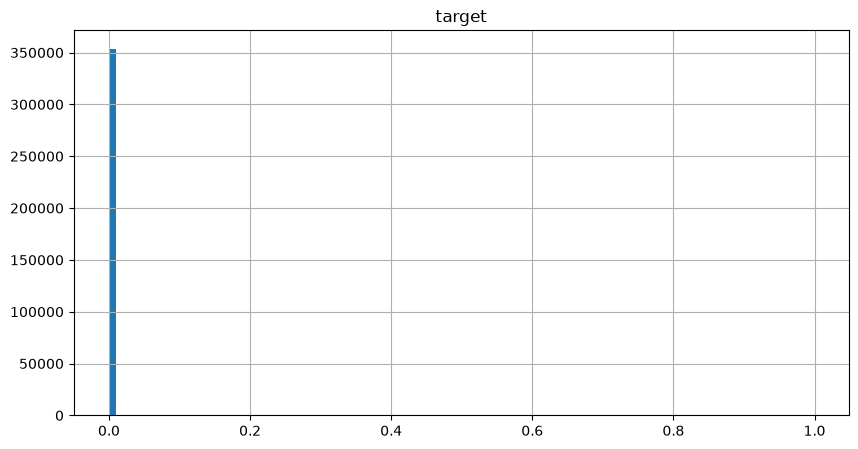

In [13]:
print('Распределение целевого признака')
data[['target']].hist(bins=100, figsize=(10,5))

 - Целевой признак имеет логнормальное распрелеление

Смотрим описание и строим гистограммы распрелеления данных в числовых признаках

In [14]:
#Признаки var10', 'var11
print('Признаки var10', 'var11')
display(data[['var10', 'var11']].describe())

Признаки var10 var11


,var10,var11
count,354208.000000,354208.000000
mean,4.121883,1327.962750
std,0.313248,1107.599507
min,3.742477,500.000000
25%,3.898949,681.909085
50%,4.039930,944.457516
75%,4.314082,1512.613632
max,5.677710,14104.377707


Распределение признаков var10, var11


array([[<Axes: title={'center': 'var10'}>,
        <Axes: title={'center': 'var11'}>]], dtype=object)

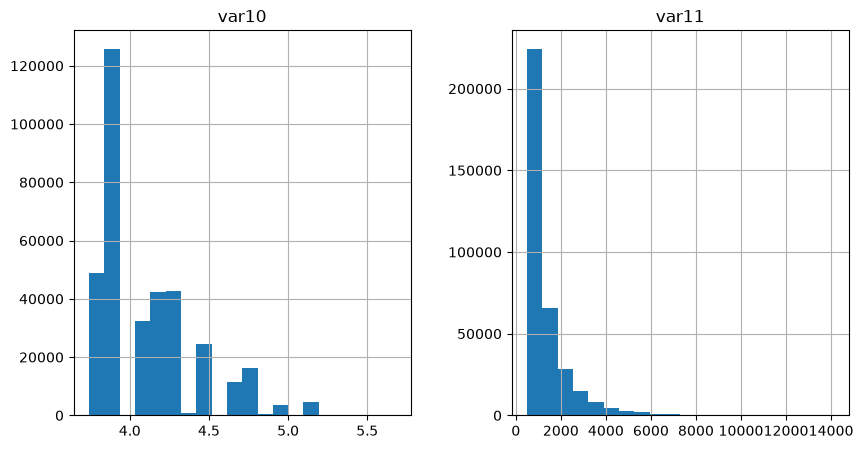

In [15]:
print('Распределение признаков var10, var11')
data[['var10', 'var11']].hist(bins=20, figsize=(10,5))

 * Распределения похожи на логнормальные

In [16]:
print('Геодемографические данные')
display(data[mask_geodem].describe())

Геодемографические данные


,geodemVar1,geodemVar2,geodemVar3,geodemVar4,geodemVar5,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10
count,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000
mean,1.133876,0.989408,1.008655,0.999934,1.289223,1.089637,0.995880,1.171155,1.005697,1.191382
std,1.908710,0.273003,0.181682,0.357395,2.511957,1.845184,0.235089,1.907143,0.122554,2.058894
min,0.000000,-0.019276,0.000000,0.000000,-2.360092,-0.000010,0.251186,0.000340,0.406282,0.000323
25%,0.089841,0.804623,0.874196,0.713666,0.025509,0.069383,0.832053,0.144064,0.936936,0.117657
50%,0.371120,0.963022,1.009916,0.981784,0.269617,0.329317,0.965496,0.474804,1.003267,0.422279
75%,1.066373,1.127096,1.141644,1.202586,1.105487,1.003778,1.122487,1.219051,1.061308,1.017501
max,8.548033,2.499209,1.943989,2.511631,11.111697,7.810601,2.692399,8.066189,1.562941,8.688013


(array([[<Axes: title={'center': 'geodemVar1'}>,
         <Axes: title={'center': 'geodemVar2'}>,
         <Axes: title={'center': 'geodemVar3'}>],
        [<Axes: title={'center': 'geodemVar4'}>,
         <Axes: title={'center': 'geodemVar5'}>,
         <Axes: title={'center': 'geodemVar6'}>],
        [<Axes: title={'center': 'geodemVar7'}>,
         <Axes: title={'center': 'geodemVar8'}>,
         <Axes: title={'center': 'geodemVar9'}>],
        [<Axes: title={'center': 'geodemVar10'}>, <Axes: >,
         <Axes: title={'center': 'Распределение геодемографических данных'}>]],
       dtype=object),
 Text(0.5, 1.0, 'Распределение геодемографических данных'))

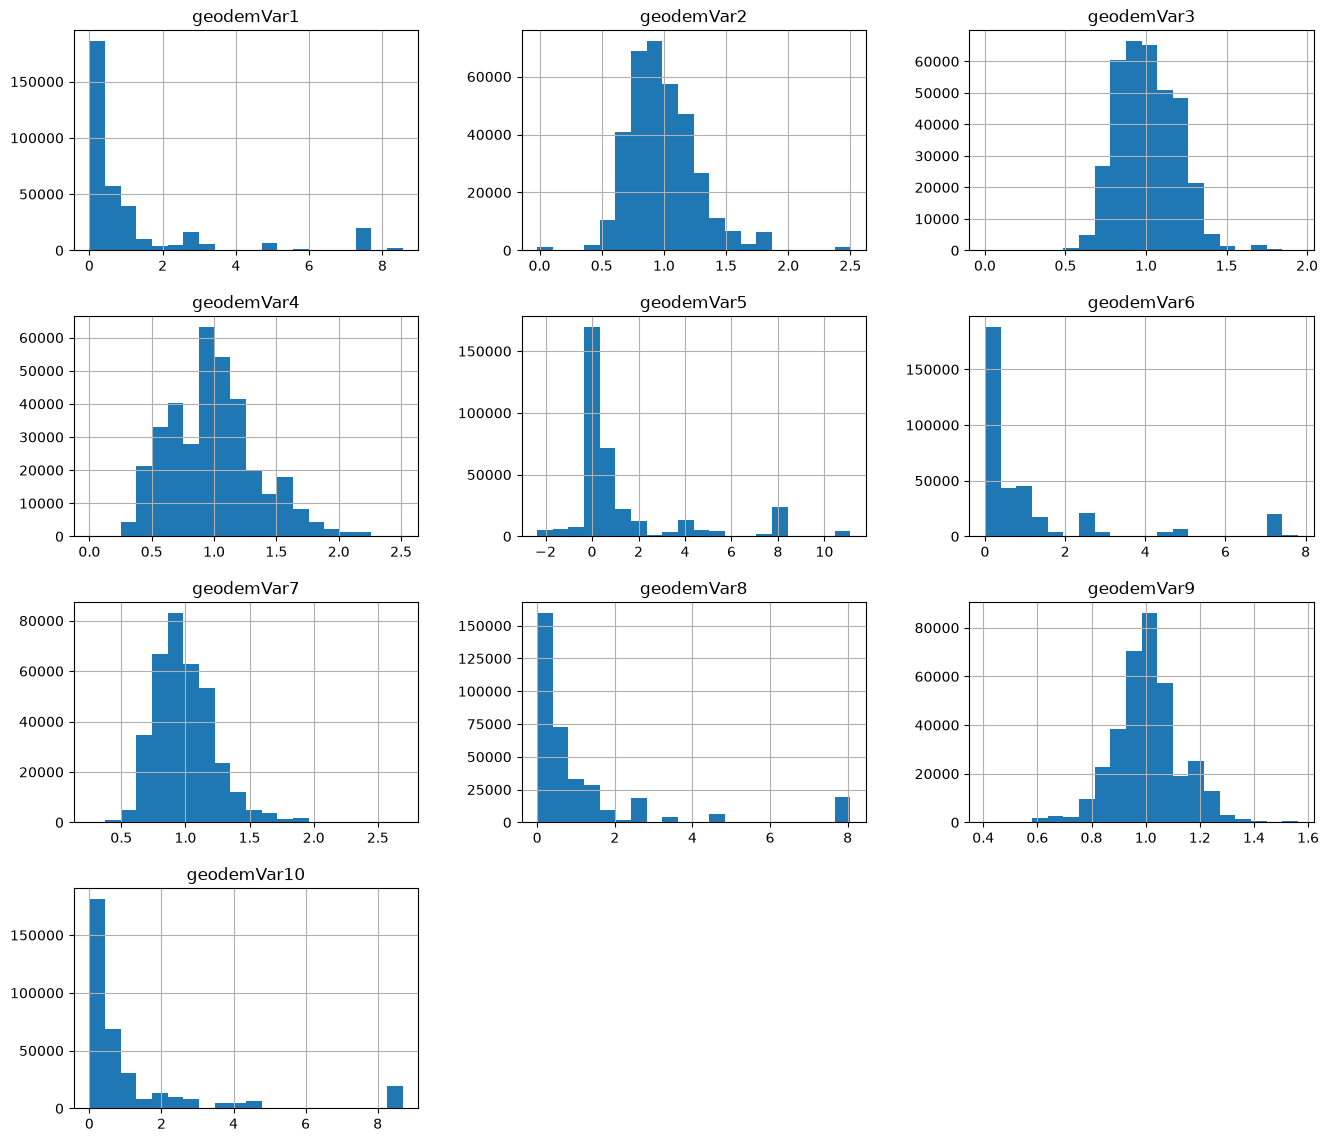

In [17]:
#print('Распределение геодемографических данных')
data[mask_geodem].hist(bins=20, figsize=(16,14)), plt.title('Распределение геодемографических данных')

 - Распределение признаков geodemVar1, geodemVar5, geodemVar6, geodemVar7, geodemVar8, geodemVar10 похожи на логнормальные
 - Есть выбросы

In [18]:
print('Метеорологические данные')
display(data[mask_weather].describe())

Метеорологические данные


,weatherVar1,weatherVar2,weatherVar3,weatherVar4,weatherVar5,weatherVar6,weatherVar7,weatherVar8,weatherVar9,weatherVar10
count,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000
mean,0.946364,0.971710,1.013386,0.971439,0.928074,0.879401,0.997746,1.381549,1.111581,0.956311
std,1.227837,5.497125,0.127058,2.232114,0.403298,2.135871,0.152631,5.850781,3.977582,0.270909
min,0.000000,0.000000,0.244720,0.000000,0.062785,0.000000,0.261188,0.000000,0.000000,0.000000
25%,0.259558,0.000000,0.906586,0.001866,0.518520,0.006410,0.912331,0.000000,0.000000,0.852964
50%,0.517654,0.000000,1.001619,0.233650,1.074387,0.271349,0.987441,0.070385,0.000000,1.003205
75%,1.172275,0.000000,1.116091,1.062357,1.260528,1.009332,1.085668,0.503185,0.442157,1.143946
max,9.098934,284.444017,1.380815,63.045569,3.038176,49.498759,1.546378,92.854862,173.182051,1.792306


(array([[<Axes: title={'center': 'weatherVar1'}>,
         <Axes: title={'center': 'weatherVar2'}>,
         <Axes: title={'center': 'weatherVar3'}>],
        [<Axes: title={'center': 'weatherVar4'}>,
         <Axes: title={'center': 'weatherVar5'}>,
         <Axes: title={'center': 'weatherVar6'}>],
        [<Axes: title={'center': 'weatherVar7'}>,
         <Axes: title={'center': 'weatherVar8'}>,
         <Axes: title={'center': 'weatherVar9'}>],
        [<Axes: title={'center': 'weatherVar10'}>, <Axes: >,
         <Axes: title={'center': 'Распреление метеорологических данных'}>]],
       dtype=object),
 Text(0.5, 1.0, 'Распреление метеорологических данных'))

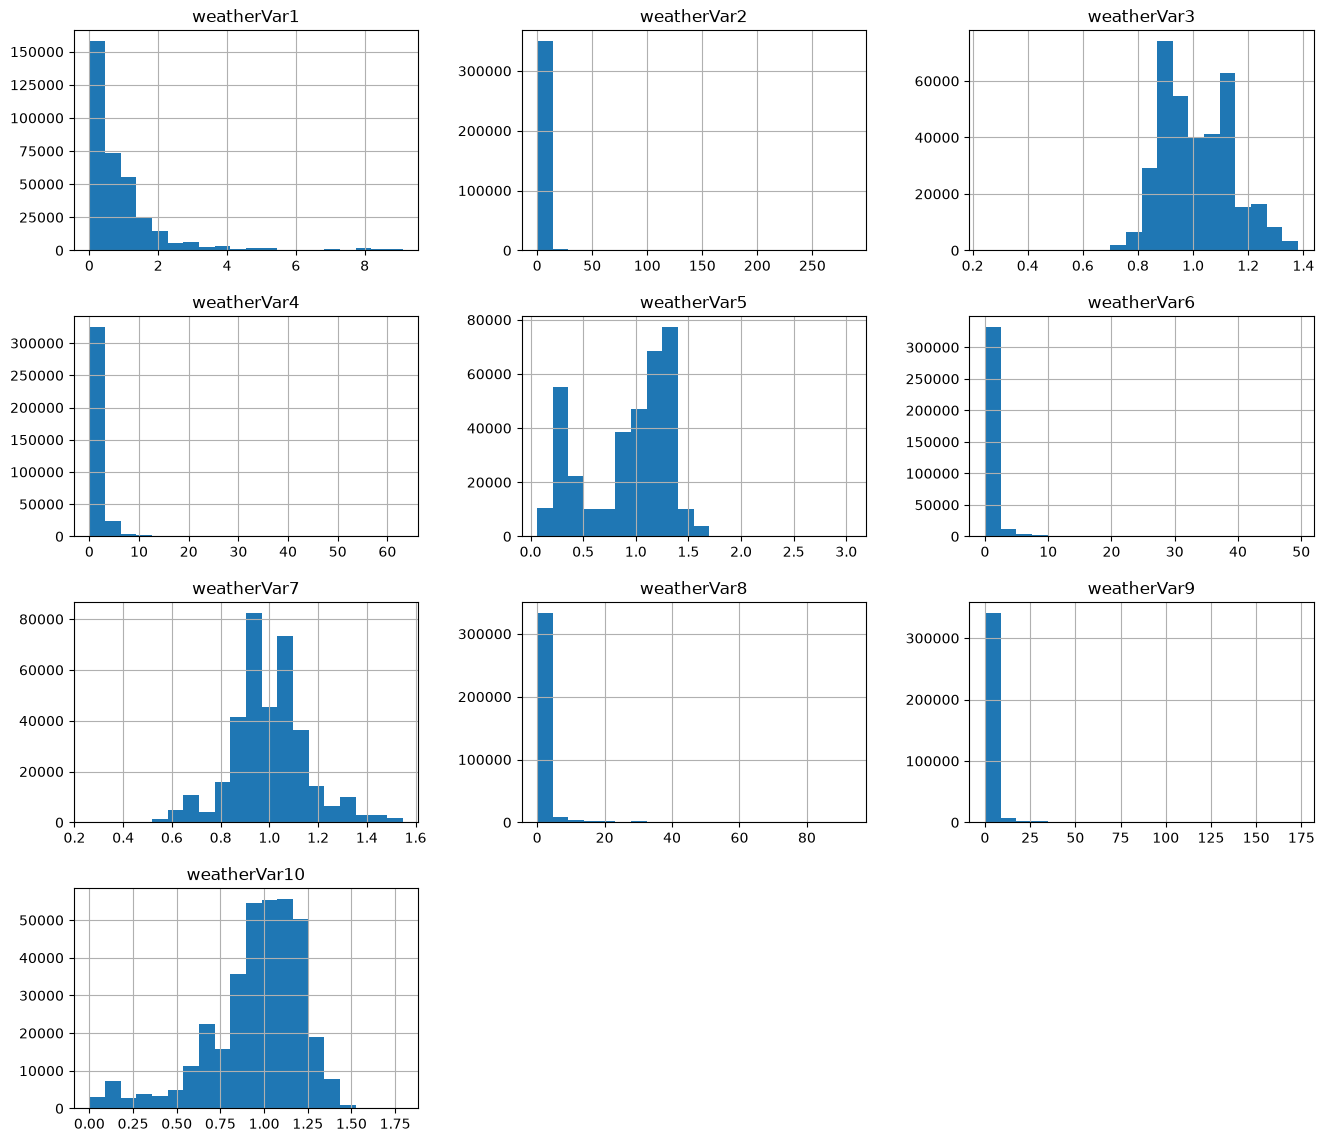

In [19]:
data[mask_weather].hist(bins=20, figsize=(16,14)), plt.title('Распреление метеорологических данных')

 - Распределение признаков weatherVar1, weatherVar2, weatherVar4, weatherVar6, weatherVar8, weatherVar9 похожина логнормальные
 - Есть выбросы

In [20]:
print('Данные о криминальной обстановке')
display(data[mask_crime].describe())

Данные о криминальной обстановке


,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
count,354208.000000,354208.000000,354208.000000,354208.000000,354208.000000
mean,1.006046,0.963150,0.970771,0.969071,1.056457
std,0.399916,0.357761,0.348093,0.228441,0.445656
min,0.083394,0.327155,0.040040,0.400622,0.121572
25%,0.867055,0.684959,0.775321,0.803309,0.739953
50%,0.919645,0.910459,0.924562,0.945046,1.035717
75%,1.066961,1.150520,1.073802,1.093863,1.322650
max,3.077587,2.970605,5.933211,2.041274,2.391149


(array([[<Axes: title={'center': 'crimeVar1'}>,
         <Axes: title={'center': 'crimeVar2'}>],
        [<Axes: title={'center': 'crimeVar3'}>,
         <Axes: title={'center': 'crimeVar4'}>],
        [<Axes: title={'center': 'crimeVar5'}>,
         <Axes: title={'center': 'Распределение данных о криминальной обстановке'}>]],
       dtype=object),
 Text(0.5, 1.0, 'Распределение данных о криминальной обстановке'))

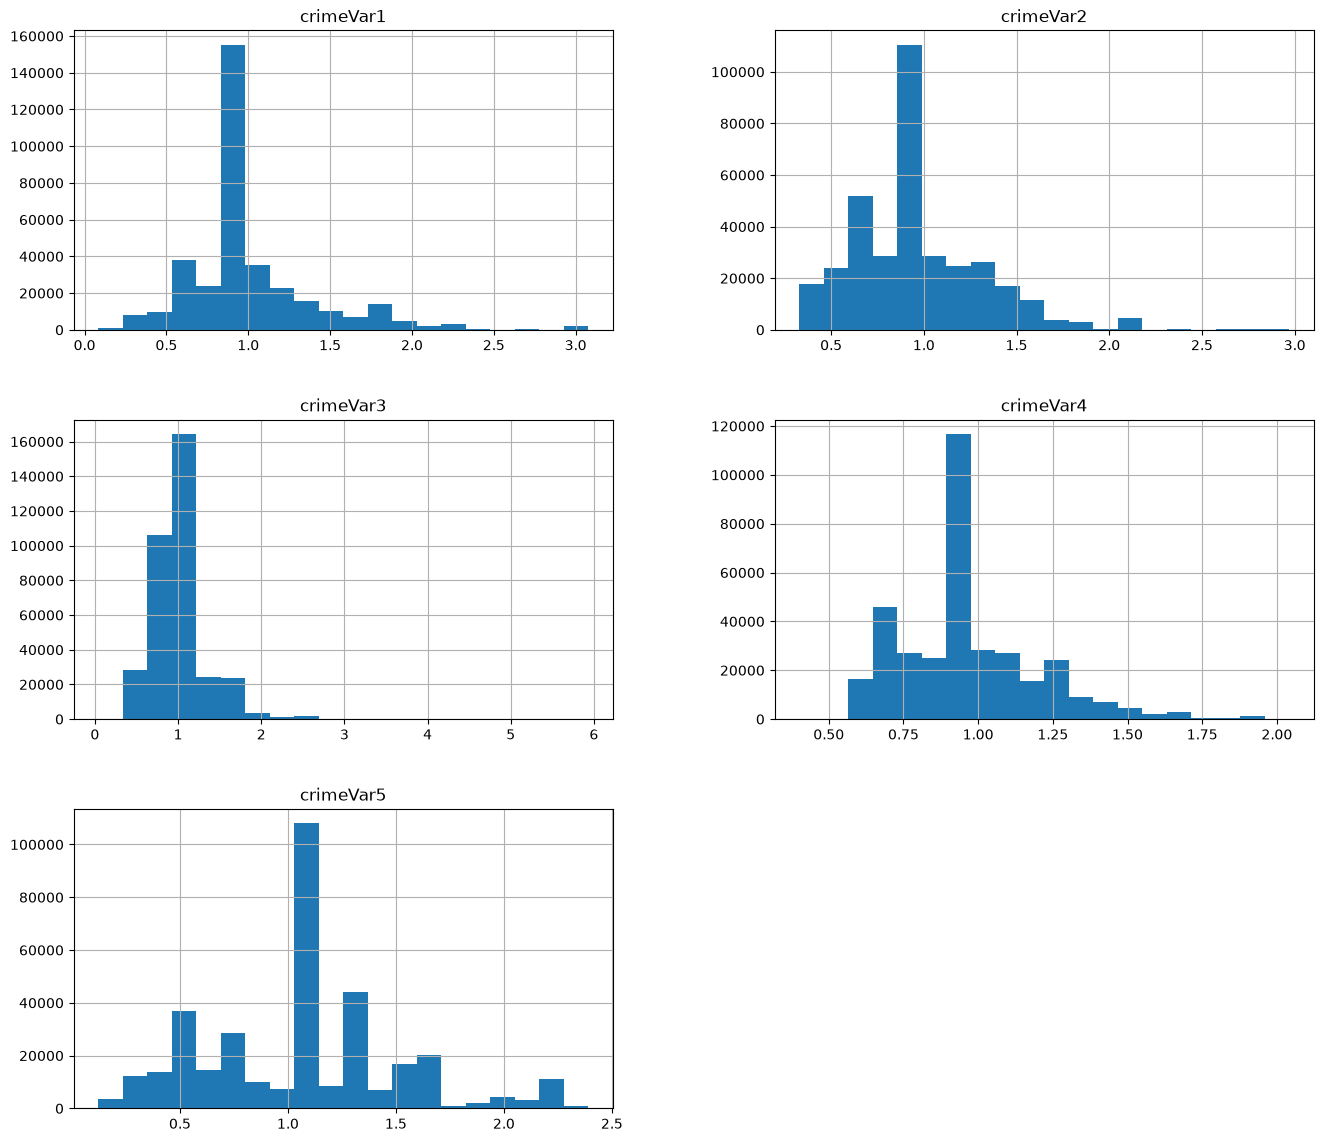

In [21]:
data[mask_crime].hist(bins=20, figsize=(16,14)), plt.title('Распределение данных о криминальной обстановке')

 - Данные crimeVar1, crimeVar2, crimeVar3, crimeVar4 похожи на логнормально распределенные;
 - Есть выбросы

In [22]:
#применим логарифмировние к признакам с логнормальными распределениями, в том числе к целевому.
log_list = ['target', 'var10', 'var11', 'geodemVar1', 'geodemVar6', 'geodemVar7', 'geodemVar8', 'geodemVar10',
            'weatherVar1', 'weatherVar2', 'weatherVar4', 'weatherVar6', 'weatherVar8', 'weatherVar9',
            'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4']


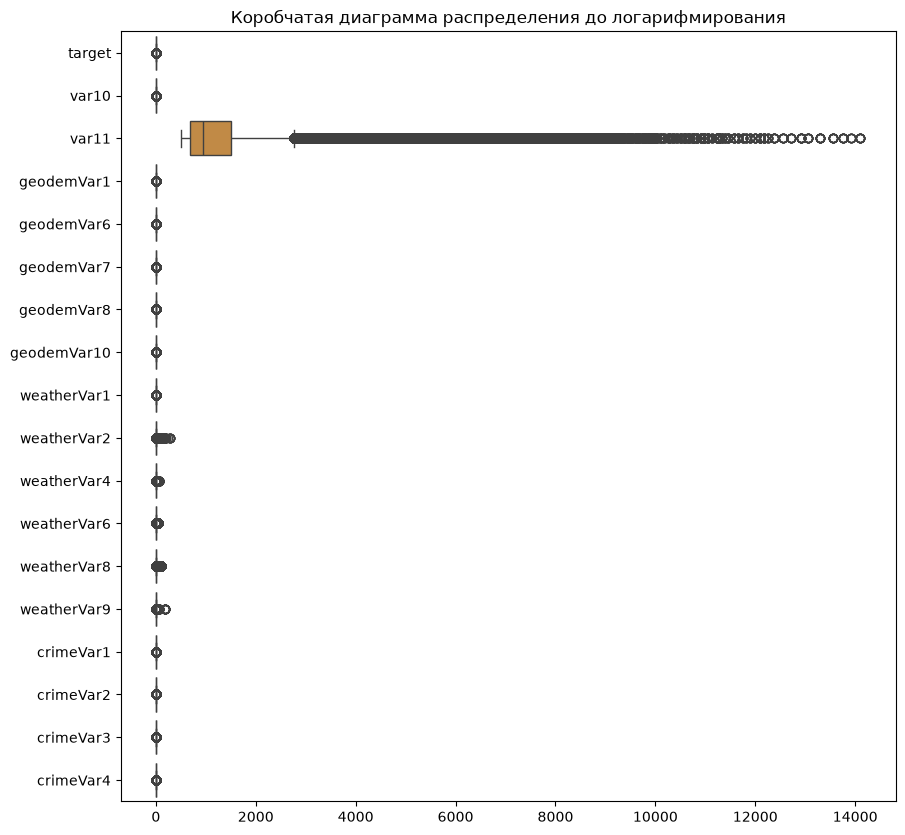

In [23]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
boxplot = sns.boxplot(data[log_list], orient='h')
boxplot.set_title('Коробчатая диаграмма распределения до логарифмирования')
plt.show()

In [24]:
data[log_list] = data[log_list].apply(lambda x: np.log(x+1))

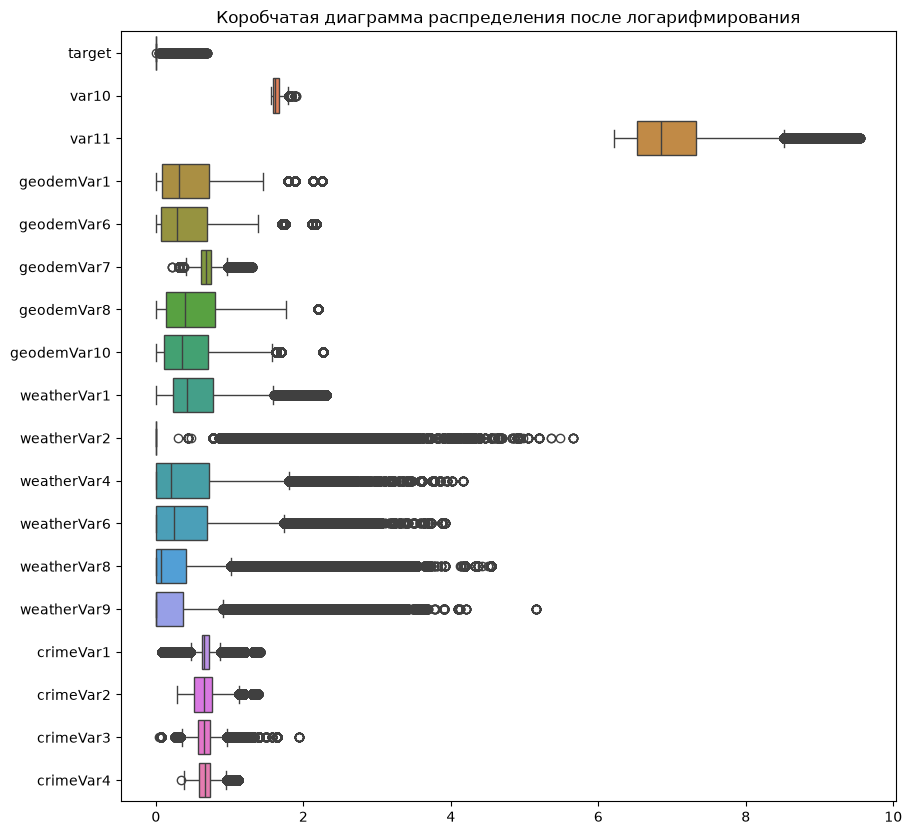

In [25]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
boxplot_log = sns.boxplot(data[log_list], orient='h')
boxplot_log.set_title('Коробчатая диаграмма распределения после логарифмирования')
plt.show()

Логарифмирвоание привело близко к нормальному распределению с небольшой ассиметрией признаки 'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4'

Очистим данные от выбросов

In [26]:
#функция определения выбросов методом Тьюки
def outliers_iqr_mod(data, feature, left = 1.5, right = 1.5):
    x = data[feature]
    quartile_1, quartile_3 = x.quantile(0.25), x.quantile(0.75)
    iqr = quartile_3 - quartile_1
    lower_bound = quartile_1 - (iqr * left)
    upper_bound = quartile_3 + (iqr * right)
    outliers_mod = data[(x < lower_bound) | (x > upper_bound)]
    cleaned_mod = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers_mod, cleaned_mod

In [27]:
#сфорируем список для ассиметричного поиска выбросов из списка логорифмированных признаков, исключив признаки 'target', 'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4'
iqr_asimmetric_list = [x for x in log_list if x not in ['target', 'crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4']]

#сформируем список для симметричного поиска выбросов
iqr_simmetric_list = [x for x in  mask_crime + mask_geodem + mask_weather if x not in iqr_asimmetric_list]

drop_list = []#список строк на удаление

for feature in iqr_simmetric_list + iqr_asimmetric_list:
    feature_drop_list = []
    if feature in iqr_simmetric_list:
        outliers, cleaned = outliers_iqr_mod(data, feature)
    if feature in iqr_asimmetric_list:
        outliers, cleaned = outliers_iqr_mod(data, feature, left = 1.5, right = 3)
    feature_drop_list = outliers.index.to_list()
    drop_list += feature_drop_list
    print(f'Число выбросов по методу Тьюки в признаке {feature}: {outliers.shape[0]}')
    #print(f'Результирующее число записей в признаке {feature}: {cleaned.shape[0]}')
drop_list = list(set(drop_list))
drop_list.sort()
#display(f'Список индексов к удалению: {drop_list}')
display(f'Количество элементов к удалению : {len(drop_list)}')

Число выбросов по методу Тьюки в признаке crimeVar1: 75762
Число выбросов по методу Тьюки в признаке crimeVar2: 3748
Число выбросов по методу Тьюки в признаке crimeVar3: 35299
Число выбросов по методу Тьюки в признаке crimeVar4: 6228
Число выбросов по методу Тьюки в признаке crimeVar5: 10224
Число выбросов по методу Тьюки в признаке geodemVar2: 10766
Число выбросов по методу Тьюки в признаке geodemVar3: 2387
Число выбросов по методу Тьюки в признаке geodemVar4: 4007
Число выбросов по методу Тьюки в признаке geodemVar5: 63142
Число выбросов по методу Тьюки в признаке geodemVar9: 16324
Число выбросов по методу Тьюки в признаке weatherVar3: 16
Число выбросов по методу Тьюки в признаке weatherVar5: 28
Число выбросов по методу Тьюки в признаке weatherVar7: 18394
Число выбросов по методу Тьюки в признаке weatherVar10: 19375
Число выбросов по методу Тьюки в признаке var10: 0
Число выбросов по методу Тьюки в признаке var11: 0
Число выбросов по методу Тьюки в признаке geodemVar1: 0
Число выброс

'Количество элементов к удалению : 215357'

In [28]:
#данные после удаления выбросов
data = data.drop(drop_list, axis = 0,).reset_index(drop=True)
data

,target,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,0.0,0,Z,0,A1,Z,Z,4,2,A,...,0.284665,0.756280,0.354811,0.970101,0.271540,0.684293,0.608789,0.534246,0.823192,1.313698
1,0.0,3,Z,3,J4,B,Z,2,4,Z,...,0.458691,0.726360,0.529396,0.986684,0.437560,0.775603,0.997142,0.873017,0.889971,1.134063
2,0.0,0,Z,0,A1,Z,Z,7,0,A,...,0.070313,0.671743,0.143296,0.994976,0.127926,0.652140,0.647343,0.654698,0.665286,1.035717
3,0.0,0,Z,0,R6,Z,Z,3,2,A,...,0.661912,0.752589,0.680869,0.949373,0.531450,0.486155,0.527241,0.529970,0.676141,0.877492
4,0.0,0,Z,0,O2,Z,Z,4,1,A,...,0.062061,0.847766,0.100497,0.820855,0.053753,0.681875,0.598094,0.700898,0.610669,0.772251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138846,0.0,0,Z,0,M1,Z,Z,4,2,A,...,0.080936,0.796011,0.229090,0.891333,0.148940,0.772659,0.664116,0.612198,0.710031,0.739953
138847,0.0,0,Z,0,O2,Z,Z,5,1,A,...,0.168514,0.813562,0.385474,0.945227,0.262705,0.652140,0.647343,0.654698,0.665286,1.035717
138848,0.0,0,Z,0,D3,Z,Z,3,2,A,...,0.987832,0.699424,0.916137,0.883041,0.747609,0.652140,0.447193,0.569461,0.553369,0.572656
138849,0.0,0,Z,0,H1,Z,Z,3,4,A,...,0.387419,0.609713,0.352895,1.090328,0.382298,0.648434,0.618475,0.886608,0.764475,1.290110


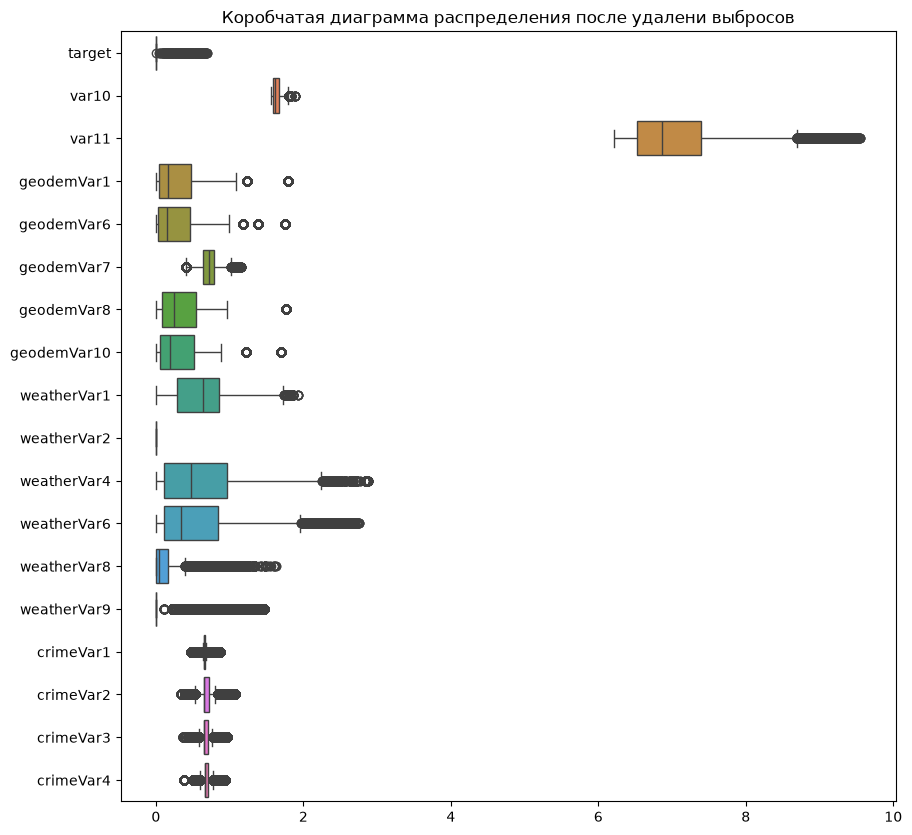

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(10, 10))
boxplot = sns.boxplot(data[log_list], orient='h')
boxplot.set_title('Коробчатая диаграмма распределения после удалени выбросов')
plt.show()

In [30]:
#Удалим признаки 'WeatherVar2','WeatherVar9' так как у них остальсь только нулевые значения
data = data.drop(['weatherVar2', 'weatherVar9'], axis = 1)

In [31]:
# Закодируем dummy признаки
data = pd.get_dummies(data, columns=['var2', 'var5', 'var6', 'var9'], drop_first=True, dtype=int)
data

,target,var1,var3,var4,var7,var8,var10,var11,weatherVar1,weatherVar3,...,var5_C,var5_D,var5_E,var5_F,var5_Z,var6_B,var6_C,var6_Z,var9_B,var9_Z
0,0.0,0,0,A1,4,2,1.573697,6.582178,0.982842,0.862954,...,0,0,0,0,1,0,0,1,0,0
1,0.0,3,3,J4,2,4,1.706396,7.760556,1.511190,1.130371,...,0,0,0,0,0,0,0,1,0,1
2,0.0,0,0,A1,7,0,1.670360,7.171903,0.684128,0.894005,...,0,0,0,0,1,0,0,1,0,0
3,0.0,0,0,R6,3,2,1.589021,6.643950,0.279944,0.906888,...,0,0,0,0,1,0,0,1,0,0
4,0.0,0,0,O2,4,1,1.589021,6.649454,0.143370,0.907333,...,0,0,0,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138846,0.0,0,0,M1,4,2,1.589021,6.692041,1.768239,0.865465,...,0,0,0,0,1,0,0,1,0,0
138847,0.0,0,0,O2,5,1,1.643108,6.938985,1.058037,0.904730,...,0,0,0,0,1,0,0,1,0,0
138848,0.0,0,0,D3,3,2,1.617392,6.783990,0.230326,0.886530,...,0,0,0,0,1,0,0,1,0,0
138849,0.0,0,0,H1,3,4,1.589021,7.499072,1.823992,0.921912,...,0,0,0,0,1,0,0,1,0,0


In [32]:
#закодируем двоичной кодировкой признак 'var4', имеющего 43 уникальных значения
bin_encoder = ce.BinaryEncoder() # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(data['var4'])
data = pd.concat([data, type_bin], axis=1)
data = data.drop('var4', axis=1)
data

,target,var1,var3,var7,var8,var10,var11,weatherVar1,weatherVar3,weatherVar4,...,var6_C,var6_Z,var9_B,var9_Z,var4_0,var4_1,var4_2,var4_3,var4_4,var4_5
0,0.0,0,0,4,2,1.573697,6.582178,0.982842,0.862954,1.167878,...,0,1,0,0,0,0,0,0,0,1
1,0.0,3,3,2,4,1.706396,7.760556,1.511190,1.130371,0.006276,...,0,1,0,1,0,0,0,0,1,0
2,0.0,0,0,7,0,1.670360,7.171903,0.684128,0.894005,0.654673,...,0,1,0,0,0,0,0,0,0,1
3,0.0,0,0,3,2,1.589021,6.643950,0.279944,0.906888,0.644713,...,0,1,0,0,0,0,0,0,1,1
4,0.0,0,0,4,1,1.589021,6.649454,0.143370,0.907333,0.153232,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138846,0.0,0,0,4,2,1.589021,6.692041,1.768239,0.865465,1.705897,...,0,1,0,0,0,0,0,1,1,1
138847,0.0,0,0,5,1,1.643108,6.938985,1.058037,0.904730,0.741437,...,0,1,0,0,0,0,0,1,0,0
138848,0.0,0,0,3,2,1.617392,6.783990,0.230326,0.886530,0.876819,...,0,1,0,0,0,0,1,1,0,0
138849,0.0,0,0,3,4,1.589021,7.499072,1.823992,0.921912,1.333642,...,0,1,0,0,0,0,1,0,0,0


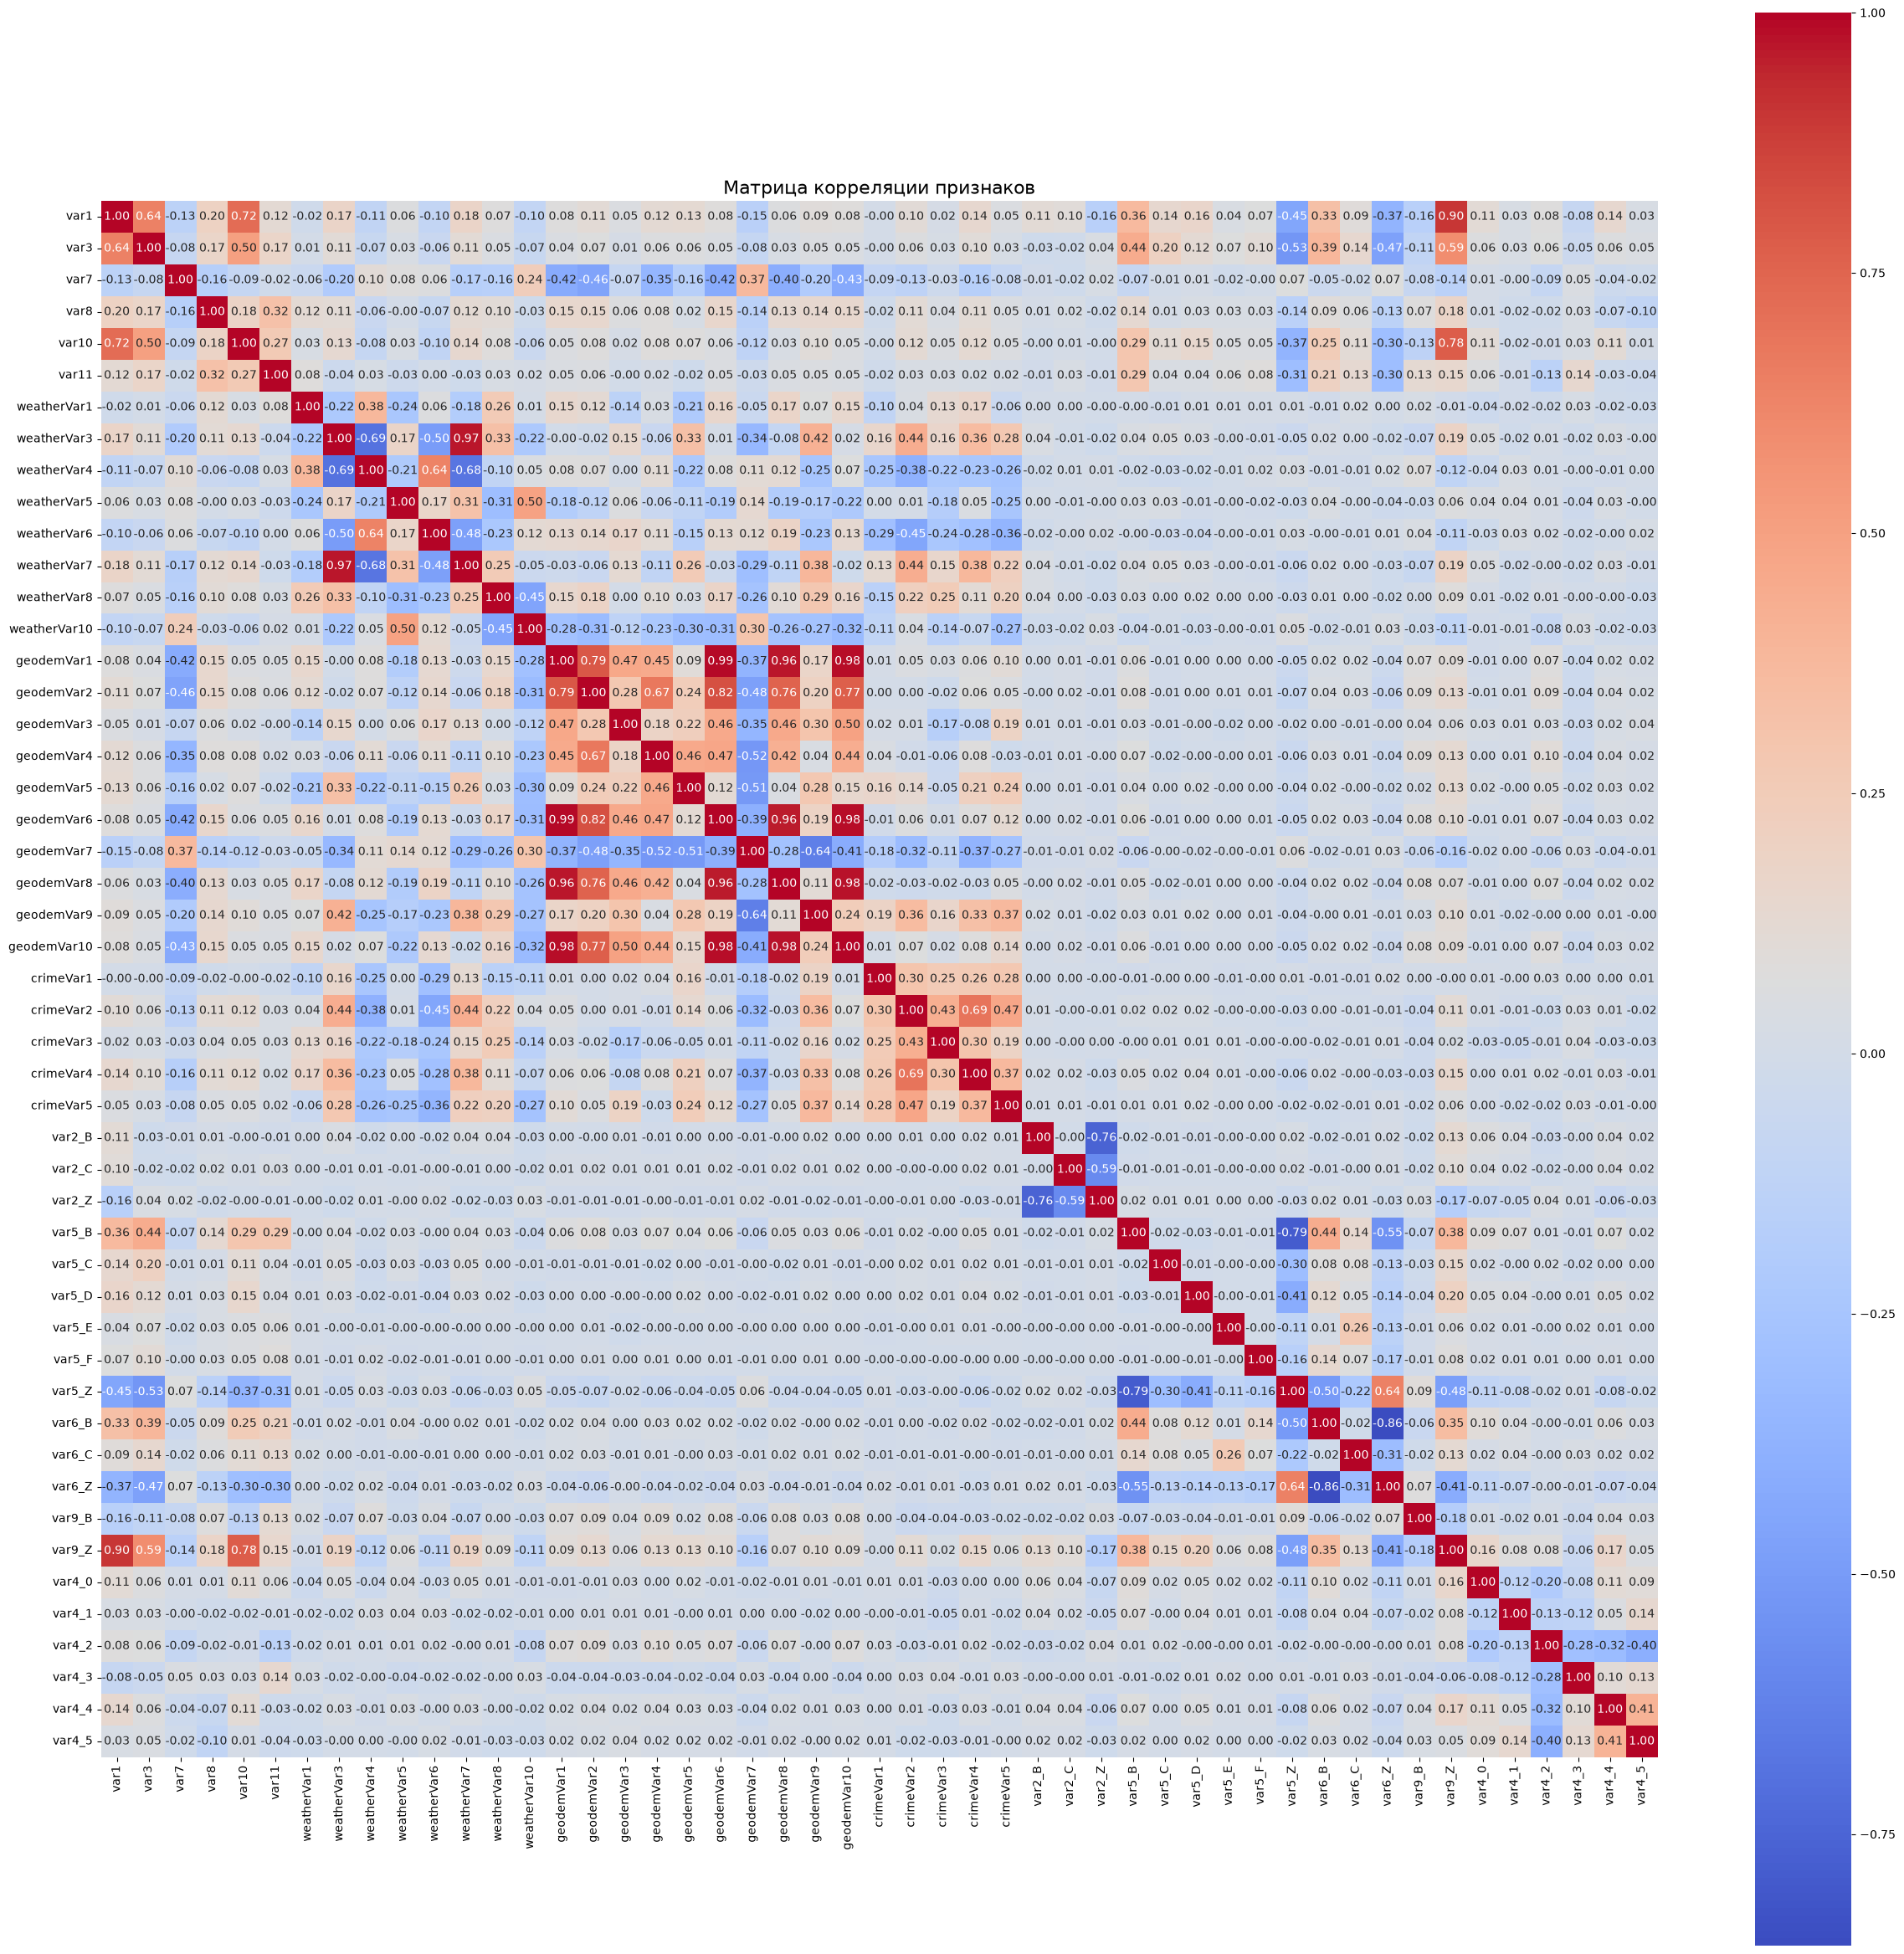

In [33]:
#корреляция признаков
corr_matrix = data.drop('target', axis=1).corr()

fig = plt.figure(figsize=(30,30))
sns.heatmap(corr_matrix, cmap = 'coolwarm', annot=True, fmt='.2f', square = True)
plt.title('Матрица корреляции признаков', fontsize=16)
plt.show()

Удалим сильно коррелирующие признаки

Используем корреляционную матрицу, чтобы найти пары признаков, которые имеют корреляцию выше заданного порога 0.7. Мы удалим один из признаков из каждой пары, чтобы избежать мультиколлинеарности.

In [34]:
# Порог корреляции
threshold = 0.7

# Из Корреляционной матрицы получаем верхний треугольник матрицы (без дублирования)
upper = corr_matrix.abs().where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))

# Список признаков с высокой корреляцией
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

# Удаляем признаки
data = data.drop(columns=to_drop)

# Список удалённых
print(f'Удаленные признаки: {to_drop}')

Удаленные признаки: ['var1', 'var10', 'weatherVar3', 'geodemVar1', 'geodemVar2', 'geodemVar6', 'geodemVar8', 'var2_B', 'var5_B', 'var6_B']


## 2. Поиск оптимальной модели регрессии

In [35]:
#Сформируем матрицу наблюдений X, вектор целевой переменной y
X = data.drop('target', axis=1)
y = data['target']

In [36]:
#Разделяем датасет на тренировочный и валидационный
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    X, y, 
    test_size=0.33, 
    random_state=42
)

In [37]:
# Нормализуйем предикторы в обучающей и валидационной выборках с помощью MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

### 2.1 Линейная регрессия

In [38]:
#Постройим модель линейной регрессии на обучающей выборке
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_lr_train_pred = lr.predict(X_train_scaled)
y_lr_valid_pred = lr.predict(X_valid_scaled)
#Рассчитываем RMSLE
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_lr_train_pred))))
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_lr_valid_pred))))

RMSLE на тренировочной выборке: 0.017
RMSLE на валидационной выборке: 0.016


### 2.2 Полиноминальная регрессия 2-ой степени

In [39]:
#Сгенерируем полиномиальные признаки 2-ой степени с помощью PolynomialFeatures
poly = preprocessing.PolynomialFeatures(degree=2, include_bias=False)
#Вычисляем параметры генерации - результирующее количество признак
poly.fit(X_train_scaled)
X_train_scaled_poly = poly.transform(X_train_scaled)
X_valid_scaled_poly = poly.transform(X_valid_scaled)

In [40]:
#Построим модель полиномиальной регрессии 2-ой степени на обучающей выборке
lr_poly = LinearRegression()
lr_poly.fit(X_train_scaled_poly, y_train)
y_poly_train_pred = lr_poly.predict(X_train_scaled_poly)
y_poly_valid_pred = lr_poly.predict(X_valid_scaled_poly)
#Рассчитываем RMSLE
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_poly_train_pred))))
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_poly_valid_pred))))

RMSLE на тренировочной выборке: 0.017
RMSLE на валидационной выборке: 0.016


 * Точность по сравнению с линейной регрессией не улучшилась. Метрика RMSLE не уменьшилась.

### 2.3 Полиномиальная регрессия 2-ой степени с L2-регуляризацией 

In [41]:
#Построим модель полиномиальной регрессии 2-ой степени с L2-регуляризацией (регуляризация по Тихонову) на обучающей выборке 
ridge_poly = Ridge(alpha = 1)
ridge_poly.fit(X_train_scaled_poly, y_train)
y_ridge_train_pred = ridge_poly.predict(X_train_scaled_poly)
y_ridge_valid_pred = ridge_poly.predict(X_valid_scaled_poly)
#Рассчитываем RMSLE
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_ridge_train_pred))))
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_ridge_valid_pred))))

RMSLE на тренировочной выборке: 0.017
RMSLE на валидационной выборке: 0.016


 * Точность по сравнению с линейной регрессией не улучшилась. Метрика RMSLE не уменьшилась.

### 2.4 Модель дерева решений (DecisionTreeRegressor)

In [42]:
#найдем оптимальные гиперпараметры для модели дерева решений
def optimaze_tree(X_train, X_test, y_train, y_test, max_depths, random_state = 42):
    max_depths = np.arange(*max_depths)
    max_depth_RMSE = pd.DataFrame()
    for max_depth in max_depths:
        tree = DecisionTreeRegressor(max_depth = max_depth, random_state = random_state )
        tree.fit(X_train, y_train)
        y_tree_train_pred = tree.predict(X_train)
        y_tree_test_pred = tree.predict(X_test)
        new_tree = pd.DataFrame({'max_depth': [max_depth],
                                  'RMSE_train': [np.sqrt(metrics.mean_squared_error(y_train, y_tree_train_pred))],
                                  'RMSE_test': [np.sqrt(metrics.mean_squared_error(y_test, y_tree_test_pred))]
                                  })
        max_depth_RMSE = pd.concat([max_depth_RMSE, new_tree], ignore_index=True)
    return max_depth_RMSE

In [43]:
max_depth_RMSLE = optimaze_tree(X_train_scaled, X_valid_scaled, y_train, y_valid, max_depths = (1, 21))
display(max_depth_RMSLE)

,max_depth,RMSE_train,RMSE_test
0,1,0.017272,0.015562
1,2,0.017241,0.015583
2,3,0.017132,0.015851
3,4,0.016983,0.016132
4,5,0.016852,0.016166
5,6,0.016584,0.016216
6,7,0.016329,0.016388
7,8,0.016095,0.016854
8,9,0.015861,0.017199
9,10,0.015436,0.017578


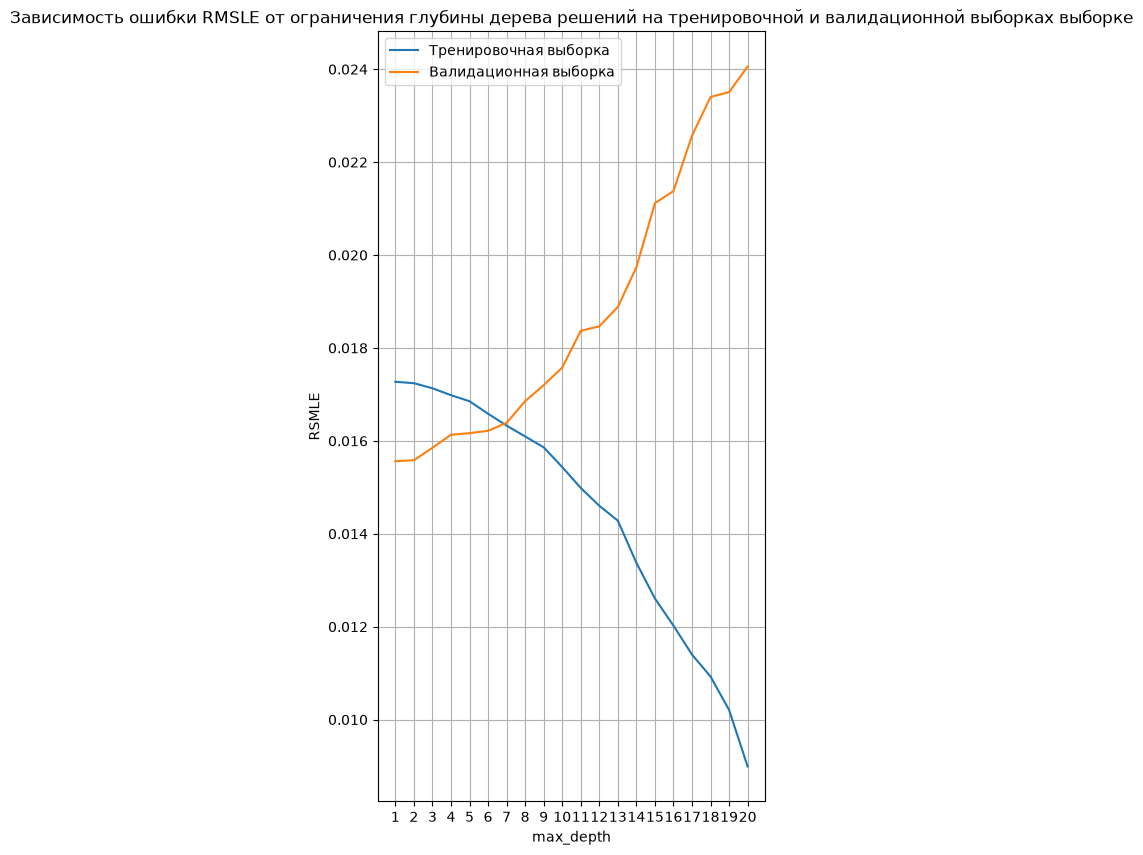

In [44]:
fig, ax = plt.subplots(1,1, figsize = (5, 10))
lineplot_1 = sns.lineplot(max_depth_RMSLE, x = 'max_depth', y = 'RMSE_train', label='Тренировочная выборка')
lineplot_2 = sns.lineplot(max_depth_RMSLE, x = 'max_depth', y = 'RMSE_test', label='Валидационная выборка')
ax.set_ylabel('RSMLE')
ax.set_title('Зависимость ошибки RMSLE от ограничения глубины дерева решений на тренировочной и валидационной выборках выборке')
ax.set_xticks(max_depth_RMSLE['max_depth'].values)
ax.grid(True)
plt.show()

*Оптимальная глубина дерева max_depth = 7.*

*RMSLE на тренировочной выборке = 0.0163.*

*RMSLE на валидационной выборке = 0.0164.*

In [45]:
#обучим дерево решений с максимальной глубиной 7
tree_7 = DecisionTreeRegressor(max_depth = 7, random_state = 42)
tree_7.fit(X_train_scaled, y_train)
y_tree_train_pred = tree_7.predict(X_train_scaled)
y_tree_valid_pred = tree_7.predict(X_valid_scaled)
#Рассчитываем RMSLE
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_tree_train_pred))))
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_tree_valid_pred))))

RMSLE на тренировочной выборке: 0.016
RMSLE на валидационной выборке: 0.016


 * Точность по сравнению с линейной регрессией не улучшилась. Метрика RMSLE не уменьшилась.

### 2.5 Модель случайного леса

In [46]:
# зададим параметры оптимизации гиперпараметров для модели случайного леса
def optuna_rf(trial):
  # задаем пространства поиска гиперпараметров
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
  max_depth = trial.suggest_int('max_depth', 2, 21, 1)
  min_samples_leaf = trial.suggest_int('min_samples_leaf', 3, 7, 1)

  # создаем модель
  model = RandomForestRegressor(n_estimators=n_estimators,
                                        max_depth=max_depth,
                                        min_samples_leaf=min_samples_leaf,
                                        random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  score = np.sqrt(metrics.mean_squared_error(y_train, y_tree_train_pred))

  return score


In [47]:
%%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо минимизировать метрику direction="minimize"
study_rf = optuna.create_study(study_name="RandomForestRegressor", direction="minimize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study_rf.optimize(optuna_rf, n_trials=20)

[I 2026-08-02 15:02:55,195] A new study created in memory with name: RandomForestRegressor
C:\Users\kryuc\AppData\Local\Temp\ipykernel_16300\3370549840.py:4: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
C:\Users\kryuc\AppData\Local\Temp\ipykernel_16300\3370549840.py:5: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the 

CPU times: total: 35min 34s
Wall time: 37min 10s


In [48]:
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study_rf.best_params))
print("RMSLE на обучающем наборе: {:.3f}".format(study_rf.best_value))


Наилучшие значения гиперпараметров {'n_estimators': 300, 'max_depth': 13, 'min_samples_leaf': 7}
RMSLE на обучающем наборе: 0.016


In [49]:
# обучим модель случайного леса с подобранными гиперпараметрами и рассчитаем точность для валидационной выборки
model_rf = RandomForestRegressor(**study_rf.best_params,random_state=42, )
model_rf.fit(X_train_scaled, y_train)
y_rf_train_pred = model_rf.predict(X_train_scaled)
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_rf_train_pred))))
y_rf_valid_pred = model_rf.predict(X_valid_scaled)
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_rf_valid_pred))))


RMSLE на тренировочной выборке: 0.016
RMSLE на валидационной выборке: 0.016


 * Точность по сравнению с линейной регрессией не улучшилась. Метрика RMSLE не уменьшилась.

### 2.6 Модель градиентного бустинга

In [50]:
# зададим параметры оптимизации гиперпараметров модели градиентного бустинга
def optuna_gb(trial):
  # задаем пространства поиска гиперпараметров
  learning_rate = trial.suggest_float('learning_rate', 0.1, 1, step=0.1)
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
  max_depth = trial.suggest_int('min_samples_split', 2, 21, 1)
  min_samples_split = trial.suggest_int('min_samples_split', 3, 7, 1)

  # создаем модель
  model = GradientBoostingRegressor(learning_rate=learning_rate,
                                        n_estimators=n_estimators,
                                        max_depth=max_depth,
                                        min_samples_split=min_samples_split,
                                        random_state=42)
  # обучаем модель
  model.fit(X_train_scaled, y_train)
  score = np.sqrt(metrics.mean_squared_error(y_train, y_tree_train_pred))

  return score


In [51]:
%%time
# cоздаем объект исследования
# можем напрямую указать, что нам необходимо минимизировать метрику direction="minimize"
study_gb = optuna.create_study(study_name="GradientBoosting", direction="minimize")
# ищем лучшую комбинацию гиперпараметров n_trials раз
study_gb.optimize(optuna_gb, n_trials=20)

[I 2026-08-02 15:43:19,647] A new study created in memory with name: GradientBoosting
C:\Users\kryuc\AppData\Local\Temp\ipykernel_16300\726011265.py:5: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresponding keyword arguments in v5.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v3.5.0 for details.
  n_estimators = trial.suggest_int('n_estimators', 100, 300, 10)
C:\Users\kryuc\AppData\Local\Temp\ipykernel_16300\726011265.py:6: FutureWarning: suggest_int() got {'step'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['self', 'name', 'low', 'high', 'step', 'log'] in suggest_int() have been deprecated since v3.5.0. They will be replaced with the corresp

CPU times: total: 51min 29s
Wall time: 2h 36min 41s


In [52]:
# выводим результаты на обучающей выборке
print("Наилучшие значения гиперпараметров {}".format(study_gb.best_params))
print("RMSLE на обучающем наборе: {:.3f}".format(study_gb.best_value))

Наилучшие значения гиперпараметров {'learning_rate': 0.7000000000000001, 'n_estimators': 260, 'min_samples_split': 6}
RMSLE на обучающем наборе: 0.016


In [53]:
#обучим модель градиентного бустинга с подобранными гиперпараметрами и рассчитаем точность для валидационной выборки
model_gb = GradientBoostingRegressor(**study_gb.best_params, random_state=42,)
model_gb.fit(X_train_scaled, y_train)
y_gb_train_pred = model_gb.predict(X_train_scaled)
y_gb_valid_pred = model_gb.predict(X_valid_scaled)
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_train, y_gb_train_pred))))
print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_valid, y_gb_valid_pred))))

RMSLE на тренировочной выборке: 0.012
RMSLE на валидационной выборке: 0.020


 * Точность по сравнению с линейной регрессией не улучшилась. Метрика RMSLE не уменьшилась.

 * Модель линейной регрессии показала сопоставимые результы с низкими показателем метрики RMSLE по сравнению с более сложными моделями для решения задачи предсазания для данного датасета

## 3 Проверка на тестовых данных

In [54]:
#загрузим тестовый набор
test = pd.read_csv('data/test_mod.csv')
test

,id,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar6,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5
0,10,0,Z,0,N1,Z,Z,4,2,A,...,0.481052,0.918399,0.470821,0.961810,0.420851,1.794760,0.936809,0.746201,1.097176,1.215352
1,11,0,Z,0,O2,Z,Z,6,4,A,...,0.050873,1.114638,0.081676,0.961810,0.060123,NaN,NaN,NaN,NaN,NaN
2,14,0,Z,0,D3,Z,Z,7,2,A,...,0.004096,1.303027,0.015707,0.928644,0.009533,NaN,NaN,NaN,NaN,NaN
3,16,2,Z,0,G1,Z,Z,5,3,Z,...,0.065149,0.989045,0.154025,0.874750,0.115253,0.710243,1.205994,1.616163,1.055174,0.727978
4,20,0,Z,0,E4,Z,Z,2,2,A,...,1.398778,1.098938,0.883918,0.596985,0.408883,1.043020,0.903848,0.912428,1.004660,2.202078
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450723,902780,0,Z,0,C1,Z,Z,1,2,A,...,7.319893,0.832053,8.066189,1.053016,8.688013,0.868651,0.625186,0.685535,0.698889,1.322650
450724,902781,3,Z,0,E3,Z,Z,3,4,Z,...,0.318891,1.067540,0.470868,0.949373,0.355629,1.209109,0.766089,1.020112,0.945046,0.775790
450725,902783,0,Z,0,C1,Z,Z,2,1,A,...,7.319893,0.832053,8.066189,1.053016,8.688013,0.868651,0.625186,0.685535,0.698889,1.322650
450726,902784,0,Z,0,O2,Z,Z,7,4,A,...,0.001465,0.965496,0.008492,0.990830,0.007435,0.744558,1.184914,1.044682,1.087479,0.752655


In [55]:
sampleSubmission = pd.read_csv('data/liberty-mutual-fire-peril/sampleSubmission.csv')
sampleSubmission

,id,target
0,10,0
1,11,0
2,14,0
3,16,0
4,20,0
...,...,...
450723,902780,0
450724,902781,0
450725,902783,0
450726,902784,0


In [56]:
test = test.merge(sampleSubmission, on='id')
test

,id,var1,var2,var3,var4,var5,var6,var7,var8,var9,...,geodemVar7,geodemVar8,geodemVar9,geodemVar10,crimeVar1,crimeVar2,crimeVar3,crimeVar4,crimeVar5,target
0,10,0,Z,0,N1,Z,Z,4,2,A,...,0.918399,0.470821,0.961810,0.420851,1.794760,0.936809,0.746201,1.097176,1.215352,0
1,11,0,Z,0,O2,Z,Z,6,4,A,...,1.114638,0.081676,0.961810,0.060123,NaN,NaN,NaN,NaN,NaN,0
2,14,0,Z,0,D3,Z,Z,7,2,A,...,1.303027,0.015707,0.928644,0.009533,NaN,NaN,NaN,NaN,NaN,0
3,16,2,Z,0,G1,Z,Z,5,3,Z,...,0.989045,0.154025,0.874750,0.115253,0.710243,1.205994,1.616163,1.055174,0.727978,0
4,20,0,Z,0,E4,Z,Z,2,2,A,...,1.098938,0.883918,0.596985,0.408883,1.043020,0.903848,0.912428,1.004660,2.202078,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450723,902780,0,Z,0,C1,Z,Z,1,2,A,...,0.832053,8.066189,1.053016,8.688013,0.868651,0.625186,0.685535,0.698889,1.322650,0
450724,902781,3,Z,0,E3,Z,Z,3,4,Z,...,1.067540,0.470868,0.949373,0.355629,1.209109,0.766089,1.020112,0.945046,0.775790,0
450725,902783,0,Z,0,C1,Z,Z,2,1,A,...,0.832053,8.066189,1.053016,8.688013,0.868651,0.625186,0.685535,0.698889,1.322650,0
450726,902784,0,Z,0,O2,Z,Z,7,4,A,...,0.965496,0.008492,0.990830,0.007435,0.744558,1.184914,1.044682,1.087479,0.752655,0


In [57]:
#Преобразование тестового набора данных аналогичные обучающему

#Удалим столбец id
test = test.drop('id', axis=1)

mask_var = [i for i in test.columns.to_list() if 'var' in i][:-2]
#Геодемографические данные
mask_geodem = [i for i in test.columns.to_list() if 'geodem' in i]

#Метеорологические данные
mask_weather = [i for i in test.columns.to_list() if 'weather' in i]

#Данные о криминальной обстановке
mask_crime = [i for i in test.columns.to_list() if 'crime' in i]

test[['var10', 'var11']] = myImputer.fit_transform(test[['var10', 'var11']])
test[mask_geodem] = myImputer.fit_transform(test[mask_geodem])
test[mask_weather] = myImputer.fit_transform(test[mask_weather])
test[mask_crime] = myImputer.fit_transform(test[mask_crime])

test = test.dropna(axis=0)

test = test.drop_duplicates(ignore_index=True)

#удалим строки с целевой переменной больше 1, так как это отношение ущерба к общей застрахованной стоимости и оно не может быть больше 1
drop_list_target = test[test['target'] > 1].index.to_list()
test = test.drop(drop_list_target, axis=0)

test[log_list] = test[log_list].apply(lambda x: np.log(x+1))

test = test.drop(drop_list, axis = 0,).reset_index(drop=True)

test = test.drop(['weatherVar2', 'weatherVar9'], axis = 1)

test = pd.get_dummies(test, columns=['var2', 'var5', 'var6', 'var9'], drop_first=True, dtype=int)

bin_encoder = ce.BinaryEncoder() # указываем столбец для кодирования
type_bin = bin_encoder.fit_transform(test['var4'])
test = pd.concat([test, type_bin], axis=1)
test = test.drop('var4', axis=1)

test = test.drop(columns=to_drop)




In [58]:
test

,var3,var7,var8,var11,weatherVar1,weatherVar4,weatherVar5,weatherVar6,weatherVar7,weatherVar8,...,var6_C,var6_Z,var9_B,var9_Z,var4_0,var4_1,var4_2,var4_3,var4_4,var4_5
0,0,3,2,7.246977,0.164733,0.000000,0.306662,0.000000,1.076561,0.949605,...,0,1,0,0,0,0,0,0,0,1
1,0,7,3,6.797301,0.271087,0.778984,1.296622,1.060047,0.895013,0.034587,...,0,1,0,0,0,0,0,0,1,0
2,0,5,2,7.479230,0.341312,0.255271,1.271770,0.966071,0.958455,0.041084,...,0,1,0,0,0,0,0,0,1,1
3,0,5,3,6.614360,0.455248,0.036929,1.284818,0.067305,1.129420,0.090235,...,0,1,0,0,0,0,0,1,0,0
4,6,5,4,8.453490,0.449429,0.497926,1.288834,1.120698,0.957823,0.071856,...,1,0,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141392,0,5,2,6.831845,0.150834,0.000000,0.297184,0.000000,1.033549,0.671068,...,0,1,0,0,0,0,0,0,0,1
141393,0,1,2,6.241238,0.152855,0.000000,0.324499,0.000000,1.094508,0.573927,...,0,1,0,0,0,0,1,0,0,0
141394,0,3,4,7.498178,0.265324,0.087142,1.202959,0.217464,0.976697,0.000000,...,0,1,0,1,0,0,0,0,1,0
141395,0,2,1,6.381027,0.227008,0.000000,0.321389,0.000000,1.052986,0.709935,...,0,1,0,0,0,0,1,0,0,0


In [59]:
X_test = test.drop('target', axis=1)
y_test = test['target']
X_test_scaled = scaler.transform(X_test)

In [60]:
#предскажем на тестовом наборе с помощью модели линейной регрессии
y_lr_test_pred = lr.predict(X_test_scaled)
#Рассчитываем RMSLE (целевой признак логарифмирован ранее)
print('RMSLE на тестовой выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_lr_test_pred))))

RMSLE на тестовой выборке: 0.002


In [61]:
#предскажем на тестовой выборке при помощи модели полиномиальной регрессии 2-ой степени 
X_test_scaled_poly = poly.transform(X_test_scaled)
y_poly_test_pred = lr_poly.predict(X_test_scaled_poly)

#Рассчитываем RMSLE

print('RMSLE на валидационной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_poly_test_pred))))

RMSLE на валидационной выборке: 0.030


In [62]:
#предскажем на тестовой выборке при помощи модели полиномиальной регрессии 2-ой степени 
y_tree_test_pred = tree_7.predict(X_test_scaled)
#Рассчитываем RMSLE
print('RMSLE на тренировочной выборке: {:.3f}'.format(np.sqrt(metrics.mean_squared_error(y_test, y_tree_test_pred))))

RMSLE на тренировочной выборке: 0.016


 * Линейная регрессия показала самую низкую метрику RMSLE по сравнению с более сложными моделями.

* Выбираем модель линейной регрессии для дальнейшего применения в продакшене 

# 4 Подготовка модели в продакшен

In [63]:
'''#сериализуем модель линейной регрессии
model_lr = pickle.dumps(lr)
#сохраняем в файл
with open('linear_regression_prediction_microservice/model/src/model_lr.pkl', 'wb') as output:
    pickle.dump(model_lr, output)'''

"#сериализуем модель линейной регрессии\nmodel_lr = pickle.dumps(lr)\n#сохраняем в файл\nwith open('linear_regression_prediction_microservice/model/src/model_lr.pkl', 'wb') as output:\n    pickle.dump(model_lr, output)"

In [64]:
#создадим свой класс для преобразования признаков
class MyTransformer(TransformerMixin, BaseEstimator):

    def transform(self, X):
        X = X.drop('id', axis=1)
        mask_var = ['var1', 'var2', 'var3', 'var4', 'var5', 'var6', 'var7', 'var8', 'var9']
        #Геодемографические данные
        mask_geodem = ['geodemVar1','geodemVar2','geodemVar3','geodemVar4','geodemVar5','geodemVar6','geodemVar7','geodemVar8','geodemVar9','geodemVar10']

        #Метеорологические данные
        mask_weather = ['weatherVar1','weatherVar2','weatherVar3','weatherVar4','weatherVar5','weatherVar6','weatherVar7','weatherVar8','weatherVar9','weatherVar10']

        #Данные о криминальной обстановке
        mask_crime = ['crimeVar1', 'crimeVar2', 'crimeVar3', 'crimeVar4', 'crimeVar5']
        
        #
        log_list = ['target','var10','var11','geodemVar1','geodemVar6','geodemVar7','geodemVar8','geodemVar10','weatherVar1',
                    'weatherVar2','weatherVar4','weatherVar6','weatherVar8','weatherVar9','crimeVar1','crimeVar2','crimeVar3',
                    'crimeVar4']

        X[log_list] = X[log_list].apply(lambda x: np.log(x+1))

        X = X.drop(['weatherVar2', 'weatherVar9'], axis = 1)

        X = pd.get_dummies(X, columns=['var2', 'var5', 'var6', 'var9'], drop_first=True, dtype=int)

        bin_encoder = ce.BinaryEncoder() # указываем столбец для кодирования
        type_bin = bin_encoder.fit_transform(X['var4'])
        X = pd.concat([X, type_bin], axis=1)
        X = X.drop('var4', axis=1)

        X = X.drop(columns=to_drop)
    
        return X

In [65]:
pipe = Pipeline([  
  ('FeatureEngineering', MyTransformer()),
  ('Scaling', MinMaxScaler()),
  ('LinearRegression', lr)
  ])

In [66]:
# Сериализуем pipeline и записываем результат в файл
with open('linear_regression_prediction_microservice/model/src/pipeline.pkl', 'wb') as output:
    pickle.dump(pipe, output)